In [1]:
import os
iskaggle = os.environ.get('KAGGLE_KERNEL_RUN_TYPE', '')

In [2]:
creds = ''

In [3]:
from pathlib import Path

cred_path = Path('~/.kaggle/kaggle.json').expanduser()
if not cred_path.exists():
    cred_path.parent.mkdir(exist_ok=True)
    cred_path.write_text(creds)
    cred_path.chmod(0o600)

In [4]:
path = Path('../input/titanic')

if not iskaggle and not path.exists():
    import zipfile, kaggle
    kaggle.api.competition_download_cli('titanic')
    zipfile.ZipFile('titanic.zip').extractall(path)

In [5]:
import torch, numpy as np, pandas as pd
np.set_printoptions(linewidth=140)
torch.set_printoptions(linewidth=140, sci_mode=False, edgeitems=7)
pd.set_option('display.width', 140)

In [6]:
df = pd.read_csv(path/'train.csv')
tst_df = pd.read_csv(path/'test.csv')
modes = df.mode().iloc[0]

In [7]:
def proc_data(df):
    df['Fare'] = df.Fare.fillna(0)
    df.fillna(modes, inplace=True)
    df['LogFare'] = np.log1p(df['Fare'])
    df['Embarked'] = pd.Categorical(df.Embarked)
    df['Sex'] = pd.Categorical(df.Sex)

proc_data(df)
proc_data(tst_df)

In [8]:
cats=["Sex","Embarked"]
conts=['Age', 'SibSp', 'Parch', 'LogFare',"Pclass"]
dep="Survived"

In [9]:
df.Sex.head()

,Sex
0,male
1,female
2,female
3,female
4,male


In [10]:
df.Sex.cat.codes.head()

,0
0,1
1,0
2,0
3,0
4,1


[Text(0.5, 1.0, 'Histogram')]

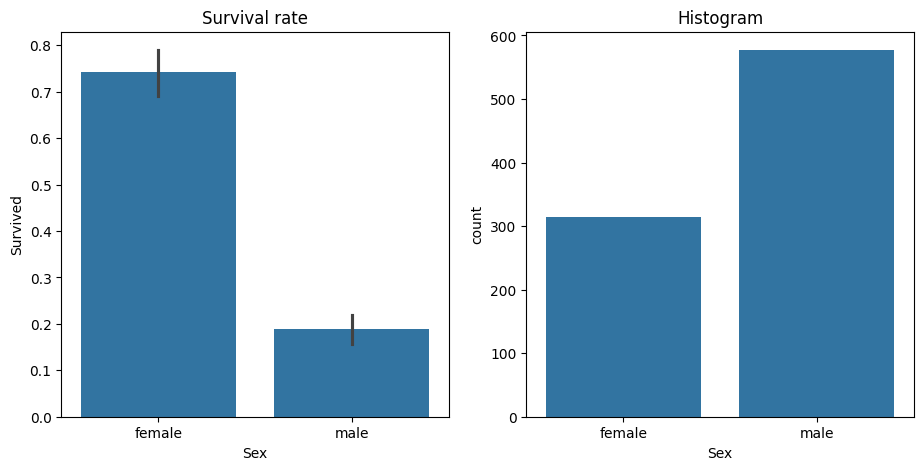

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt
fig,axs = plt.subplots(1,2, figsize=(11,5))
sns.barplot(data=df, y=dep, x="Sex", ax=axs[0]).set(title="Survival rate")
sns.countplot(data=df, x="Sex", ax=axs[1]).set(title="Histogram")

# We could create a very simple "model" which simply says that all females survive, and no males do.

In [12]:
from numpy import random
from sklearn.model_selection import train_test_split

random.seed(42)
trn_df,val_df = train_test_split(df, test_size=0.25)
trn_df[cats] = trn_df[cats].apply(lambda x: x.cat.codes)
val_df[cats] = val_df[cats].apply(lambda x: x.cat.codes)

In [13]:
def xs_y(df):
    xs = df[cats+conts].copy()
    return xs,df[dep] if dep in df else None

trn_xs,trn_y = xs_y(trn_df)
val_xs,val_y = xs_y(val_df)

In [14]:
preds = val_xs.Sex==0

In [15]:
from sklearn.metrics import mean_absolute_error
mean_absolute_error(val_y, preds)

0.21524663677130046

# Here's an example of how we could look at LogFare

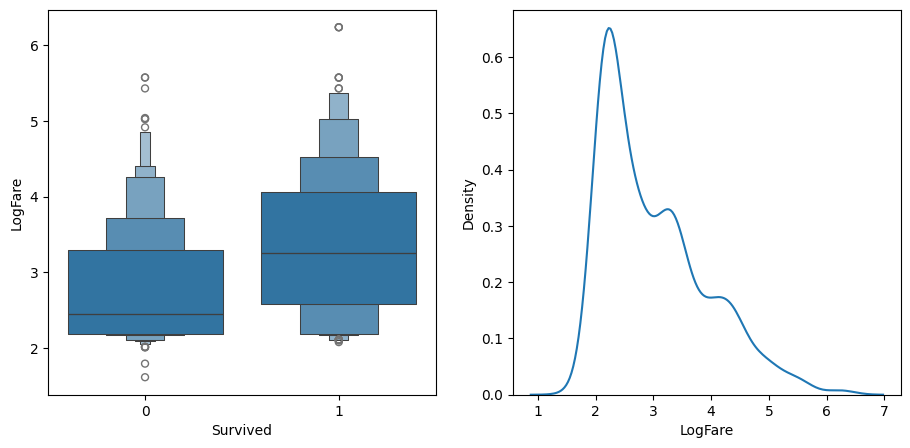

In [16]:
df_fare = trn_df[trn_df.LogFare>0]
fig,axs = plt.subplots(1,2, figsize=(11,5))
sns.boxenplot(data=df_fare, x=dep, y="LogFare", ax=axs[0])
sns.kdeplot(data=df_fare, x="LogFare", ax=axs[1]);

# So it seems that people that paid more for their tickets were more likely to get put on a lifeboat.

In [17]:
preds = val_xs.LogFare>2.7
mean_absolute_error(val_y, preds)

0.336322869955157

# We'll create a score function to do this. Instead of returning the mean absolute error, we'll calculate a measure of impurity

In [18]:
def _side_score(side, y):
    tot = side.sum()
    if tot<=1: return 0
    return y[side].std()*tot

we can calculate the score for a split by adding up the scores for the "left hand side" (lhs) and "right hand side" (rhs)

In [19]:
def score(col, y, split):
    lhs = col<=split
    return (_side_score(lhs,y) + _side_score(~lhs,y))/len(y)

In [20]:
score(trn_xs["Sex"], trn_y, 0.5)

np.float64(0.4078753098206398)

In [21]:
score(trn_xs["LogFare"], trn_y, 2.7)

np.float64(0.4718087395209973)

As we'd expect from our earlier tests, Sex appears to be a better split.

In [22]:
def iscore(nm, split):
    col = trn_xs[nm]
    return score(col, trn_y, split)

from ipywidgets import interact
interact(nm=conts, split=15.5)(iscore);

interactive(children=(Dropdown(description='nm', options=('Age', 'SibSp', 'Parch', 'LogFare', 'Pclass'), value…

In [23]:
interact(nm=cats, split=2)(iscore)

interactive(children=(Dropdown(description='nm', options=('Sex', 'Embarked'), value='Sex'), IntSlider(value=2,…

<function __main__.iscore(nm, split)>

In [24]:
nm = "Age"
col = trn_xs[nm]
unq = col.unique()
unq.sort()
unq

array([ 0.42,  0.67,  0.75,  0.83,  0.92,  1.  ,  2.  ,  3.  ,  4.  ,  5.  ,  6.  ,  7.  ,  8.  ,  9.  , 10.  , 11.  , 12.  , 13.  , 14.  ,
       14.5 , 15.  , 16.  , 17.  , 18.  , 19.  , 20.  , 21.  , 22.  , 23.  , 24.  , 24.5 , 25.  , 26.  , 27.  , 28.  , 28.5 , 29.  , 30.  ,
       31.  , 32.  , 32.5 , 33.  , 34.  , 34.5 , 35.  , 36.  , 36.5 , 37.  , 38.  , 39.  , 40.  , 40.5 , 41.  , 42.  , 43.  , 44.  , 45.  ,
       45.5 , 46.  , 47.  , 48.  , 49.  , 50.  , 51.  , 52.  , 53.  , 54.  , 55.  , 55.5 , 56.  , 57.  , 58.  , 59.  , 60.  , 61.  , 62.  ,
       64.  , 65.  , 70.  , 70.5 , 74.  , 80.  ])

In [25]:
scores = np.array([score(col, trn_y, o) for o in unq if not np.isnan(o)])
unq[scores.argmin()]

np.float64(6.0)

In [26]:
def min_col(df, nm):
    col,y = df[nm],df[dep]
    unq = col.dropna().unique()
    scores = np.array([score(col, y, o) for o in unq if not np.isnan(o)])
    idx = scores.argmin()
    return unq[idx],scores[idx]

min_col(trn_df, "Age")

(np.float64(6.0), np.float64(0.47831671750899085))

In [27]:
cols = cats+conts
{o:min_col(trn_df, o) for o in cols}

{'Sex': (np.int8(0), np.float64(0.4078753098206398)),
 'Embarked': (np.int8(0), np.float64(0.478833425731479)),
 'Age': (np.float64(6.0), np.float64(0.47831671750899085)),
 'SibSp': (np.int64(4), np.float64(0.4783740258817423)),
 'Parch': (np.int64(0), np.float64(0.4805296527841601)),
 'LogFare': (np.float64(2.4390808375825834), np.float64(0.4620823937736595)),
 'Pclass': (np.int64(2), np.float64(0.4604826188580666))}

# According to this, Sex<=0 is the best split we can use.

In [28]:
cols.remove("Sex")
ismale = trn_df.Sex==1
males,females = trn_df[ismale],trn_df[~ismale]

In [29]:
{o:min_col(males, o) for o in cols}

{'Embarked': (np.int8(0), np.float64(0.387558187041091)),
 'Age': (np.float64(6.0), np.float64(0.37398283710105873)),
 'SibSp': (np.int64(4), np.float64(0.38758642275862637)),
 'Parch': (np.int64(0), np.float64(0.3874704821461953)),
 'LogFare': (np.float64(2.803360380906535), np.float64(0.38048562317581447)),
 'Pclass': (np.int64(1), np.float64(0.3815544200436083))}

In [30]:
{o:min_col(females, o) for o in cols}

{'Embarked': (np.int8(0), np.float64(0.4295252982857326)),
 'Age': (np.float64(50.0), np.float64(0.4225927658431646)),
 'SibSp': (np.int64(4), np.float64(0.42319212059713585)),
 'Parch': (np.int64(3), np.float64(0.4193314500446157)),
 'LogFare': (np.float64(4.256321678298823), np.float64(0.413505983329114)),
 'Pclass': (np.int64(2), np.float64(0.3335388911567602))}

We can see that the best next binary split for males is Age<=6, and for females is Pclass<=2

In [31]:
from sklearn.tree import DecisionTreeClassifier, export_graphviz

m = DecisionTreeClassifier(max_leaf_nodes=4).fit(trn_xs, trn_y);

In [32]:
import graphviz
import re
def draw_tree(t, df, size=10, ratio=0.6, precision=2, **kwargs):
    s=export_graphviz(t, out_file=None, feature_names=df.columns, filled=True, rounded=True,
                      special_characters=True, rotate=False, precision=precision, **kwargs)
    return graphviz.Source(re.sub('Tree {', f'Tree {{ size={size}; ratio={ratio}', s))

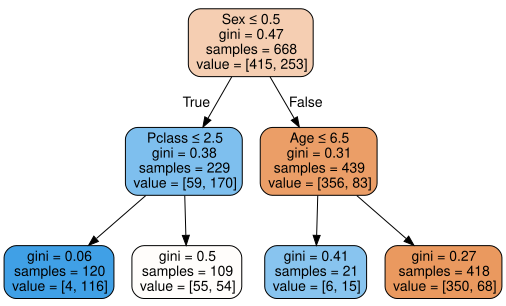

In [33]:
draw_tree(m, trn_xs, size=10)

We can see that it's found exactly the same splits as we did!

In this picture, the more orange nodes have a lower survival rate, and blue have higher survival

There's also something called "gini". That's another measure of impurity, and it's very similar to the score() we created earlier.

In [34]:
def gini(cond):
    act = df.loc[cond, dep]
    return 1 - act.mean()**2 - (1-act).mean()**2

In [35]:
gini(df.Sex=='female'), gini(df.Sex=='male')

(np.float64(0.3828350034484158), np.float64(0.3064437162277842))

In [36]:
mean_absolute_error(val_y, m.predict(val_xs))

0.2242152466367713

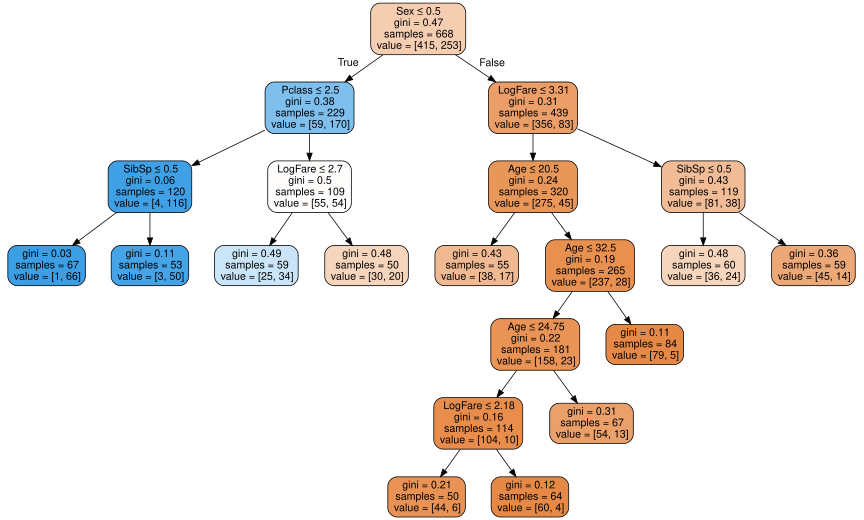

In [37]:
m = DecisionTreeClassifier(min_samples_leaf=50)
m.fit(trn_xs, trn_y)
draw_tree(m, trn_xs, size=12)

In [38]:
mean_absolute_error(val_y, m.predict(val_xs))

0.18385650224215247

We can't make the decision tree much bigger than the example above, since some leaf nodes already have only 50 rows in them. That's not a lot of data to make a prediction.

One way we can create a bunch of uncorrelated models is to train each of them on a different random subset of the data

In [39]:
def get_tree(prop=0.75):
    n = len(trn_y)
    idxs = random.choice(n, int(n*prop))
    return DecisionTreeClassifier(min_samples_leaf=5).fit(trn_xs.iloc[idxs], trn_y.iloc[idxs])

In [40]:
trees = [get_tree() for t in range(100)]

In [41]:
all_probs = [t.predict(val_xs) for t in trees]
avg_probs = np.stack(all_probs).mean(0)

mean_absolute_error(val_y, avg_probs)

0.2272645739910314

In [42]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(100, min_samples_leaf=5)
rf.fit(trn_xs, trn_y);
mean_absolute_error(val_y, rf.predict(val_xs))

0.18834080717488788

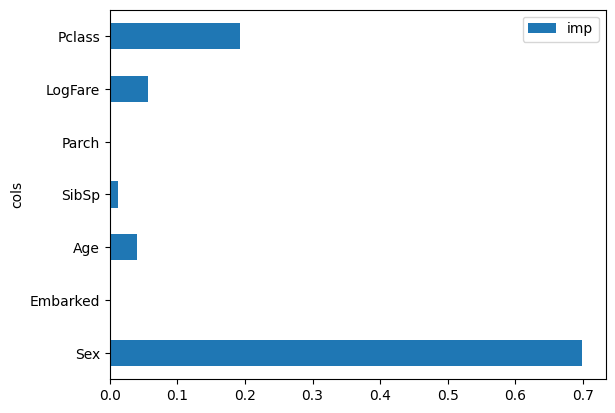

In [43]:
pd.DataFrame(dict(cols=trn_xs.columns, imp=m.feature_importances_)).plot('cols', 'imp', 'barh');

We can see that Sex is by far the most important predictor, with Pclass a distant second, and LogFare and Age behind that.